# KNU 2026 ML Final Assignment - p4
## Changes from p3
1. Remove per-PID rest-baseline feature normalization entirely. It helped Rest and pulled active classes toward Rest.
2. Keep device normalization with unknown-device fallback and keep direction-corrected body axes.
3. Keep jerk, but only on targeted channels: `amag`, `azb`, `gmag` in short and long windows.
4. Fix lateral asymmetry as `abs(mean(xb)) / std(xb)` instead of the collapsed positive/negative formula.
5. Add autocorrelation features at five lags on the targeted long-window channels to measure motion repeatability.
6. Restore LightGBM to p2-style `learning_rate=0.05` and `early_stopping=100`.
7. Increase CatBoost capacity to `depth=10`, `iterations=4000`.
8. Evaluate pure CatBoost and CatBoost-heavy blends on OOF, then apply soft probability smoothing with explicit per-PID time sorting.


In [1]:
!pip install lightgbm catboost scikit-learn pandas numpy scipy -q


[notice] A new release of pip is available: 26.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.signal import find_peaks
from scipy.fft import rfft, rfftfreq
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import GroupKFold
from sklearn.metrics import balanced_accuracy_score

import lightgbm as lgb
import catboost as cb

import os


In [3]:
# Configuration
DATA_DIR = '/Users/dayana/git repo/machine-learning-class/lab6/knu-2026-machine-learning-final-assignment'
SEED     = 42
N_FOLDS  = 5

# p4: revert LGBM to p2-style slower learning and longer patience.
LGBM_PARAMS = {
    'objective':        'multiclass',
    'num_class':        9,
    'metric':           'multi_logloss',
    'learning_rate':    0.05,
    'num_leaves':       127,
    'max_depth':        -1,
    'min_child_samples': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq':     1,
    'lambda_l1':        0.1,
    'lambda_l2':        0.1,
    'verbose':          -1,
    'n_jobs':           -1,
    'seed':             SEED,
}

# p4: more CatBoost capacity. Fold 1 in p3 was still learning deep into training.
CAT_PARAMS = {
    'iterations':           4000,
    'learning_rate':        0.05,
    'depth':                10,
    'l2_leaf_reg':          3,
    'loss_function':        'MultiClass',
    'eval_metric':          'TotalF1:average=Macro',
    'early_stopping_rounds': 200,
    'random_seed':          SEED,
    'verbose':              0,
    'allow_writing_files':   False,
}

print("Config loaded.")


Config loaded.


In [4]:
# ── Load Raw Data ───────────────────────────────────────────
print("Loading sensor files (this may take ~1-2 minutes)...")

train_accel = pd.read_csv(os.path.join(DATA_DIR, 'train-accel.csv'))
train_gyro  = pd.read_csv(os.path.join(DATA_DIR, 'train-gyro.csv'))
train_label = pd.read_csv(os.path.join(DATA_DIR, 'train-label.csv'))

test_accel  = pd.read_csv(os.path.join(DATA_DIR, 'test-accel.csv'))
test_gyro   = pd.read_csv(os.path.join(DATA_DIR, 'test-gyro.csv'))
test_label  = pd.read_csv(os.path.join(DATA_DIR, 'test-label.csv'))

print(f"train_accel : {train_accel.shape}")
print(f"train_gyro  : {train_gyro.shape}")
print(f"train_label : {train_label.shape}")
print(f"test_accel  : {test_accel.shape}")
print(f"test_gyro   : {test_gyro.shape}")
print(f"test_label  : {test_label.shape}")


Loading sensor files (this may take ~1-2 minutes)...
train_accel : (2428374, 7)
train_gyro  : (2433673, 7)
train_label : (38015, 4)
test_accel  : (2528310, 7)
test_gyro   : (2541831, 7)
test_label  : (39473, 4)


In [5]:
# Device Normalization + Unknown Device Fallback - kept from p3
# This is sensor/device normalization, not per-PID rest-baseline feature normalization.
# Test rows with the unseen `unknown` device fall back to global train stats.

def normalize_by_device(df_train, df_test, axes=['x', 'y', 'z']):
    """
    Z-score normalize sensor axes per device using train statistics.
    Unknown/unseen test devices fall back to global train mean/std.
    """
    df_train = df_train.copy()
    df_test  = df_test.copy()

    # Pre-compute global fallback stats from ALL train rows
    global_stats = {}
    for ax in axes:
        global_stats[ax] = (df_train[ax].mean(), df_train[ax].std() + 1e-8)

    # Per-device normalization
    known_devices = set(df_train['device'].unique())
    for device in known_devices:
        tr_mask = df_train['device'] == device
        te_mask = df_test['device'] == device
        for ax in axes:
            mu  = df_train.loc[tr_mask, ax].mean()
            sig = df_train.loc[tr_mask, ax].std() + 1e-8
            df_train.loc[tr_mask, ax] = (df_train.loc[tr_mask, ax] - mu) / sig
            df_test.loc[te_mask,  ax] = (df_test.loc[te_mask,  ax] - mu) / sig

    # Fallback: normalize test rows whose device was NOT in train
    unknown_mask = ~df_test['device'].isin(known_devices)
    if unknown_mask.sum() > 0:
        print(f"  Applying global fallback normalization to {unknown_mask.sum()} rows "
              f"with unseen device(s): {df_test.loc[unknown_mask, 'device'].unique()}")
        for ax in axes:
            mu, sig = global_stats[ax]
            df_test.loc[unknown_mask, ax] = (df_test.loc[unknown_mask, ax] - mu) / sig

    return df_train, df_test

print("Normalizing accel by device...")
train_accel, test_accel = normalize_by_device(train_accel, test_accel)

print("Normalizing gyro by device...")
train_gyro, test_gyro = normalize_by_device(train_gyro, test_gyro)

print("Device normalization done.")
print(f"  Devices in train_accel: {train_accel['device'].unique()}")
print(f"  Devices in test_accel : {test_accel['device'].unique()}")


Normalizing accel by device...
  Applying global fallback normalization to 92768 rows with unseen device(s): <StringArray>
['unknown']
Length: 1, dtype: str
Normalizing gyro by device...
  Applying global fallback normalization to 92737 rows with unseen device(s): <StringArray>
['unknown']
Length: 1, dtype: str
Device normalization done.
  Devices in train_accel: <StringArray>
['samsung', 'Apple']
Length: 2, dtype: str
  Devices in test_accel : <StringArray>
['unknown', 'samsung', 'Apple']
Length: 3, dtype: str


In [6]:
# ── Direction-Corrected Axes (unchanged from p2) ────────────
def apply_direction_correction(df):
    """
    Rotate x, y, z into canonical body frame based on phone direction.
    Adds columns: xb (lateral), yb (forward/back), zb (vertical), magb.
    """
    df = df.copy()
    df['xb'] = df['x'].copy()
    df['yb'] = df['y'].copy()
    df['zb'] = df['z'].copy()

    for d, (sx, sy, sz) in {
        1: ( 'y', '-x',  'z'),
        2: ('-y',  'x',  'z'),
        3: ( 'y', '-x', '-z'),
        4: ('-y',  'x', '-z'),
    }.items():
        mask = df['direction'] == d
        df.loc[mask, 'xb'] = (df.loc[mask, 'x'] if sx == 'x'
                               else -df.loc[mask, 'x'] if sx == '-x'
                               else  df.loc[mask, 'y'] if sx == 'y'
                               else -df.loc[mask, 'y'])
        df.loc[mask, 'yb'] = (df.loc[mask, 'x'] if sy == 'x'
                               else -df.loc[mask, 'x'] if sy == '-x'
                               else  df.loc[mask, 'y'] if sy == 'y'
                               else -df.loc[mask, 'y'])
        df.loc[mask, 'zb'] = (df.loc[mask, 'z'] if sz == 'z'
                               else -df.loc[mask, 'z'])

    df['magb'] = np.sqrt(df['xb']**2 + df['yb']**2 + df['zb']**2)
    return df

print("Applying direction correction to accel...")
train_accel = apply_direction_correction(train_accel)
test_accel  = apply_direction_correction(test_accel)

print("Applying direction correction to gyro...")
train_gyro  = apply_direction_correction(train_gyro)
test_gyro   = apply_direction_correction(test_gyro)

print("Direction correction done.")
print("Sample accel after correction:")
print(train_accel[['direction','x','y','z','xb','yb','zb','magb']].head(4))


Applying direction correction to accel...
Applying direction correction to gyro...
Direction correction done.
Sample accel after correction:
   direction         x         y         z        xb        yb        zb  \
0        1.0  0.745617  0.275943  0.651492  0.275943 -0.745617  0.651492   
1        1.0  0.742578  0.250713  0.667765  0.250713 -0.742578  0.667765   
2        1.0  0.748189  0.216309  0.660485  0.216309 -0.748189  0.660485   
3        1.0  0.754735  0.227777  0.643784  0.227777 -0.754735  0.643784   

       magb  
0  1.027877  
1  1.029654  
2  1.021184  
3  1.017824  


In [7]:
# Feature Extraction Helpers
FS = 50.0  # nominal sampling rate in Hz

# ────────────────────────────────────────────────────────────
# STAT FEATURES  (unchanged from p2 — 17 per channel)
# ────────────────────────────────────────────────────────────
def stat_features(arr, prefix):
    feats = {}
    n = len(arr)
    if n == 0:
        for k in ['mean','std','var','min','max','range','median',
                  'p25','p75','iqr','skew','kurt','rms','energy',
                  'zero_cross','mean_abs_diff','max_abs']:
            feats[f'{prefix}_{k}'] = 0.0
        return feats
    feats[f'{prefix}_mean']          = np.mean(arr)
    feats[f'{prefix}_std']           = np.std(arr)
    feats[f'{prefix}_var']           = np.var(arr)
    feats[f'{prefix}_min']           = np.min(arr)
    feats[f'{prefix}_max']           = np.max(arr)
    feats[f'{prefix}_range']         = np.ptp(arr)
    feats[f'{prefix}_median']        = np.median(arr)
    feats[f'{prefix}_p25']           = np.percentile(arr, 25)
    feats[f'{prefix}_p75']           = np.percentile(arr, 75)
    feats[f'{prefix}_iqr']           = np.percentile(arr, 75) - np.percentile(arr, 25)
    feats[f'{prefix}_skew']          = float(stats.skew(arr))     if n > 2 else 0.0
    feats[f'{prefix}_kurt']          = float(stats.kurtosis(arr)) if n > 2 else 0.0
    feats[f'{prefix}_rms']           = np.sqrt(np.mean(arr**2))
    feats[f'{prefix}_energy']        = np.sum(arr**2) / n
    feats[f'{prefix}_zero_cross']    = np.sum(np.diff(np.sign(arr - np.mean(arr))) != 0) / max(n-1, 1)
    feats[f'{prefix}_mean_abs_diff'] = np.mean(np.abs(np.diff(arr))) if n > 1 else 0.0
    feats[f'{prefix}_max_abs']       = np.max(np.abs(arr))
    return feats


# ────────────────────────────────────────────────────────────
# FFT FEATURES  (unchanged from p2 — 7 per channel)
# ────────────────────────────────────────────────────────────
def fft_features(arr, prefix, fs=FS):
    feats = {}
    n = len(arr)
    if n < 8:
        for k in ['dom_freq','dom_amp','spectral_entropy',
                  'band_low','band_mid','band_high','band_ratio_mid_low']:
            feats[f'{prefix}_{k}'] = 0.0
        return feats

    arr_centered = arr - np.mean(arr)
    fft_vals = np.abs(rfft(arr_centered))
    freqs    = rfftfreq(n, d=1.0/fs)
    total_power = np.sum(fft_vals**2) + 1e-10

    dom_idx = np.argmax(fft_vals)
    feats[f'{prefix}_dom_freq'] = freqs[dom_idx]
    feats[f'{prefix}_dom_amp']  = fft_vals[dom_idx]

    psd_norm = fft_vals**2 / total_power
    psd_norm = psd_norm[psd_norm > 0]
    feats[f'{prefix}_spectral_entropy'] = -np.sum(psd_norm * np.log(psd_norm + 1e-10))

    low_mask  = (freqs >= 0.0) & (freqs < 1.0)
    mid_mask  = (freqs >= 1.0) & (freqs < 3.0)
    high_mask = (freqs >= 3.0) & (freqs < 8.0)

    feats[f'{prefix}_band_low']  = np.sum(fft_vals[low_mask]**2)  / total_power
    feats[f'{prefix}_band_mid']  = np.sum(fft_vals[mid_mask]**2)  / total_power
    feats[f'{prefix}_band_high'] = np.sum(fft_vals[high_mask]**2) / total_power
    feats[f'{prefix}_band_ratio_mid_low'] = (
        feats[f'{prefix}_band_mid'] / (feats[f'{prefix}_band_low'] + 1e-10)
    )
    return feats


# ────────────────────────────────────────────────────────────
# PEAK FEATURES  (unchanged from p2 — 6 per channel)
# ────────────────────────────────────────────────────────────
def peak_features(arr, prefix, fs=FS):
    feats = {}
    n = len(arr)
    if n < 4:
        for k in ['n_peaks','peak_rate','mean_peak_height',
                  'std_peak_height','mean_peak_interval','peak_regularity']:
            feats[f'{prefix}_{k}'] = 0.0
        return feats

    arr_centered  = arr - np.mean(arr)
    height_thresh = 0.3 * np.std(arr_centered)
    peaks, props  = find_peaks(arr_centered,
                                height=height_thresh,
                                distance=int(fs * 0.15))
    n_peaks    = len(peaks)
    duration_s = n / fs

    feats[f'{prefix}_n_peaks']   = n_peaks
    feats[f'{prefix}_peak_rate'] = n_peaks / duration_s

    if n_peaks > 0:
        ph = props['peak_heights']
        feats[f'{prefix}_mean_peak_height'] = np.mean(ph)
        feats[f'{prefix}_std_peak_height']  = np.std(ph)
    else:
        feats[f'{prefix}_mean_peak_height'] = 0.0
        feats[f'{prefix}_std_peak_height']  = 0.0

    if n_peaks > 1:
        intervals = np.diff(peaks) / fs
        feats[f'{prefix}_mean_peak_interval'] = np.mean(intervals)
        feats[f'{prefix}_peak_regularity']    = 1.0 / (np.std(intervals) + 1e-6)
    else:
        feats[f'{prefix}_mean_peak_interval'] = 0.0
        feats[f'{prefix}_peak_regularity']    = 0.0

    return feats


# ────────────────────────────────────────────────────────────
# POSTURE FEATURES  (unchanged from p2 — 5 features)
# ────────────────────────────────────────────────────────────
def posture_features(a_xb, a_yb, a_zb):
    feats = {}
    if len(a_xb) == 0:
        feats.update({
            'posture_zb_mean': 0.0, 'posture_yb_mean': 0.0,
            'posture_tilt_angle': 0.0, 'posture_prone_score': 0.0,
            'posture_vertical_energy': 0.0,
        })
        return feats

    grav_x = np.mean(a_xb)
    grav_y = np.mean(a_yb)
    grav_z = np.mean(a_zb)
    grav_mag = np.sqrt(grav_x**2 + grav_y**2 + grav_z**2) + 1e-8

    feats['posture_zb_mean']        = grav_z
    feats['posture_yb_mean']        = grav_y
    feats['posture_tilt_angle']     = np.arccos(np.clip(abs(grav_y) / grav_mag, 0, 1))
    feats['posture_prone_score']    = abs(grav_z) / grav_mag
    dynamic_zb = np.array(a_zb) - grav_z
    feats['posture_vertical_energy'] = np.mean(dynamic_zb**2)
    return feats


# ────────────────────────────────────────────────────────────
# p4 - TARGETED JERK FEATURES
# First derivative of acceleration = jerk.
# JumpSquat: huge jerk at takeoff + landing.
# MtnClimb: rapid small jerks from alternating legs.
# PushUp:   slow smooth jerk (no impulse).
# Squat:    low smooth jerk.
# Rest:     near-zero jerk.
# We extract stat features on the jerk signal (13 features per channel).
# ────────────────────────────────────────────────────────────
def jerk_features(arr, prefix, fs=FS):
    """
    Compute jerk (d/dt of signal) and extract key statistics.
    Uses 13 features: mean_abs, std, max_abs, rms, energy,
    p90_abs, p95_abs, skew, kurt, n_peaks, peak_rate,
    mean_peak_height, impulse_ratio.
    """
    feats = {}
    keys = ['mean_abs','std','max_abs','rms','energy',
            'p90_abs','p95_abs','skew','kurt',
            'n_peaks','peak_rate','mean_peak_height','impulse_ratio']
    if len(arr) < 2:
        for k in keys:
            feats[f'{prefix}_{k}'] = 0.0
        return feats

    jerk = np.diff(arr.astype(np.float64)) * fs   # units per second²
    n    = len(jerk)

    feats[f'{prefix}_mean_abs']  = np.mean(np.abs(jerk))
    feats[f'{prefix}_std']       = np.std(jerk)
    feats[f'{prefix}_max_abs']   = np.max(np.abs(jerk))
    feats[f'{prefix}_rms']       = np.sqrt(np.mean(jerk**2))
    feats[f'{prefix}_energy']    = np.sum(jerk**2) / n
    feats[f'{prefix}_p90_abs']   = np.percentile(np.abs(jerk), 90)
    feats[f'{prefix}_p95_abs']   = np.percentile(np.abs(jerk), 95)
    feats[f'{prefix}_skew']      = float(stats.skew(jerk))     if n > 2 else 0.0
    feats[f'{prefix}_kurt']      = float(stats.kurtosis(jerk)) if n > 2 else 0.0

    # Peaks in |jerk| — captures explosive impulses
    abs_jerk = np.abs(jerk)
    thresh   = 0.5 * np.std(abs_jerk)
    peaks, props = find_peaks(abs_jerk, height=thresh, distance=int(fs * 0.1))
    n_peaks    = len(peaks)
    duration_s = n / fs
    feats[f'{prefix}_n_peaks']   = n_peaks
    feats[f'{prefix}_peak_rate'] = n_peaks / duration_s
    feats[f'{prefix}_mean_peak_height'] = (
        np.mean(props['peak_heights']) if n_peaks > 0 else 0.0
    )
    # Impulse ratio: max jerk / mean jerk — high for jump exercises, low for smooth ones
    mean_abs = feats[f'{prefix}_mean_abs'] + 1e-10
    feats[f'{prefix}_impulse_ratio'] = feats[f'{prefix}_max_abs'] / mean_abs

    return feats


# -----------------------------------------------------------------------------
# p4 - FIXED LATERAL ASYMMETRY FEATURES
# Body-frame xb axis = lateral direction. The p3 positive/negative formula
# collapsed toward zero after centering. p4 uses raw lateral offset strength:
# abs(mean(xb)) / std(xb). Lunge should be higher; centered squat should be low.
# -----------------------------------------------------------------------------
def lateral_asymmetry_features(axb, prefix='lat'):
    feats = {}
    keys = ['xb_skew','xb_kurt','xb_asymmetry_idx',
            'xb_pos_ratio','xb_range_ratio','xb_mean_abs']
    arr = np.asarray(axb, dtype=np.float64)
    arr = arr[np.isfinite(arr)]
    if len(arr) < 4:
        for k in keys:
            feats[f'{prefix}_{k}'] = 0.0
        return feats

    arr_c = arr - np.mean(arr)
    feats[f'{prefix}_xb_skew']  = float(stats.skew(arr_c))     if len(arr) > 2 else 0.0
    feats[f'{prefix}_xb_kurt']  = float(stats.kurtosis(arr_c)) if len(arr) > 2 else 0.0

    # Fixed p4 asymmetry: persistent lateral offset scaled by variability.
    feats[f'{prefix}_xb_asymmetry_idx'] = float(abs(np.mean(arr)) / (np.std(arr) + 1e-8))

    pos_vals = arr[arr > 0]
    feats[f'{prefix}_xb_pos_ratio'] = float(len(pos_vals) / len(arr))
    feats[f'{prefix}_xb_range_ratio'] = float(np.max(arr_c) / (abs(np.min(arr_c)) + 1e-8))
    feats[f'{prefix}_xb_mean_abs'] = float(np.mean(np.abs(arr_c)))
    return feats


# -----------------------------------------------------------------------------
# p4 - AUTOCORRELATION FEATURES
# FFT says which frequency dominates; autocorrelation says how cleanly repeated
# the motion is. JumpSquat should be strong around repeated jump lags; Lunge is
# more asymmetric and should be weaker/less regular inside the same window.
# -----------------------------------------------------------------------------
def autocorr_features(arr, prefix, fs=FS, lags_s=(0.5, 1.0, 1.5, 2.0, 2.5)):
    feats = {}
    lag_names = [str(lag).replace('.', 'p') for lag in lags_s]
    keys = [f'lag_{name}' for name in lag_names] + ['max', 'mean', 'std', 'best_lag_s']

    arr = np.asarray(arr, dtype=np.float64)
    arr = arr[np.isfinite(arr)]
    if len(arr) < int(max(lags_s) * fs) + 2 or np.std(arr) < 1e-8:
        for k in keys:
            feats[f'{prefix}_{k}'] = 0.0
        return feats

    x = arr - np.mean(arr)
    x = x / (np.std(x) + 1e-8)
    vals = []
    for lag_s, lag_name in zip(lags_s, lag_names):
        lag = int(round(lag_s * fs))
        if lag <= 0 or len(x) <= lag:
            ac = 0.0
        else:
            ac = float(np.mean(x[:-lag] * x[lag:]))
        feats[f'{prefix}_lag_{lag_name}'] = ac
        vals.append(ac)

    vals = np.asarray(vals, dtype=np.float64)
    feats[f'{prefix}_max'] = float(np.max(vals))
    feats[f'{prefix}_mean'] = float(np.mean(vals))
    feats[f'{prefix}_std'] = float(np.std(vals))
    feats[f'{prefix}_best_lag_s'] = float(lags_s[int(np.argmax(vals))])
    return feats


print("Feature extraction helpers defined.")
print(f"  stat_features              : 17 per channel (unchanged)")
print(f"  fft_features               : 7  per channel (unchanged)")
print(f"  peak_features              : 6  per channel (unchanged)")
print(f"  posture_features           : 5  (unchanged)")
print(f"  jerk_features    [p4 targeted] : 13 per selected channel")
print(f"  lateral_asymmetry [p4 fixed]    : 6 per window")
print(f"  autocorr_features [NEW p4]      : 5 lags + summary per channel")


Feature extraction helpers defined.
  stat_features              : 17 per channel (unchanged)
  fft_features               : 7  per channel (unchanged)
  peak_features              : 6  per channel (unchanged)
  posture_features           : 5  (unchanged)
  jerk_features    [p4 targeted] : 13 per selected channel
  lateral_asymmetry [p4 fixed]    : 6 per window
  autocorr_features [NEW p4]      : 5 lags + summary per channel


In [8]:
# Main Feature Extraction Function - p4
CONTEXT_SHORT = 1   # ±1s for stat features
CONTEXT_LONG  = 4   # ±4s for FFT, peak, jerk features

def compute_features_p4(accel_df, gyro_df, label_df):
    """
    Extract all p4 features for each (pid, time_s) in label_df.
    p4 removes rest-baseline normalization, narrows jerk to targeted channels,
    fixes lateral asymmetry, and adds autocorrelation features.
    """
    accel_df = accel_df.copy()
    gyro_df  = gyro_df.copy()
    label_df = label_df.copy()

    accel_df['time_s'] = accel_df['time'].astype(int)
    gyro_df['time_s']  = gyro_df['time'].astype(int)
    label_df['time_s'] = label_df['time'].astype(int)

    for df in [accel_df, gyro_df]:
        df['mag'] = np.sqrt(df['x']**2 + df['y']**2 + df['z']**2)

    print("  Building sensor lookup tables...")

    def build_lookup(df, cols):
        lookup = {}
        for (pid, ts), grp in df.groupby(['pid', 'time_s']):
            lookup[(pid, ts)] = grp[cols].values
        return lookup

    accel_raw_lookup  = build_lookup(accel_df, ['x','y','z','mag'])
    accel_body_lookup = build_lookup(accel_df, ['xb','yb','zb','magb'])
    gyro_raw_lookup   = build_lookup(gyro_df,  ['x','y','z','mag'])
    gyro_body_lookup  = build_lookup(gyro_df,  ['xb','yb','zb','magb'])

    meta_lookup = {}
    for (pid, ts), grp in accel_df.groupby(['pid', 'time_s']):
        meta_lookup[(pid, ts)] = {
            'direction': grp['direction'].iloc[0],
            'device':    1 if str(grp['device'].iloc[0]).lower() == 'apple' else 0,
        }

    print("  Extracting features per label row (this takes a few minutes)...")
    all_feats = []

    for idx, (_, row) in enumerate(label_df.iterrows()):
        pid = row['pid']
        ts  = int(row['time_s'])
        feat = {}

        # ── Collect SHORT window arrays (±1s)
        ax_s, ay_s, az_s, amag_s      = [], [], [], []
        gx_s, gy_s, gz_s, gmag_s      = [], [], [], []
        axb_s, ayb_s, azb_s            = [], [], []

        for offset in range(-CONTEXT_SHORT, CONTEXT_SHORT + 1):
            key = (pid, ts + offset)
            if key in accel_raw_lookup:
                c = accel_raw_lookup[key]
                ax_s.extend(c[:,0]); ay_s.extend(c[:,1])
                az_s.extend(c[:,2]); amag_s.extend(c[:,3])
            if key in accel_body_lookup:
                c = accel_body_lookup[key]
                axb_s.extend(c[:,0]); ayb_s.extend(c[:,1]); azb_s.extend(c[:,2])
            if key in gyro_raw_lookup:
                c = gyro_raw_lookup[key]
                gx_s.extend(c[:,0]); gy_s.extend(c[:,1])
                gz_s.extend(c[:,2]); gmag_s.extend(c[:,3])

        # ── Collect LONG window arrays (±4s)
        amag_l, axb_l, ayb_l, azb_l   = [], [], [], []
        gmag_l, gxb_l, gyb_l, gzb_l   = [], [], [], []

        for offset in range(-CONTEXT_LONG, CONTEXT_LONG + 1):
            key = (pid, ts + offset)
            if key in accel_raw_lookup:
                c = accel_raw_lookup[key]; amag_l.extend(c[:,3])
            if key in accel_body_lookup:
                c = accel_body_lookup[key]
                axb_l.extend(c[:,0]); ayb_l.extend(c[:,1]); azb_l.extend(c[:,2])
            if key in gyro_raw_lookup:
                c = gyro_raw_lookup[key]; gmag_l.extend(c[:,3])
            if key in gyro_body_lookup:
                c = gyro_body_lookup[key]
                gxb_l.extend(c[:,0]); gyb_l.extend(c[:,1]); gzb_l.extend(c[:,2])

        # numpy conversion
        ax_s   = np.array(ax_s,   dtype=np.float32)
        ay_s   = np.array(ay_s,   dtype=np.float32)
        az_s   = np.array(az_s,   dtype=np.float32)
        amag_s = np.array(amag_s, dtype=np.float32)
        gx_s   = np.array(gx_s,   dtype=np.float32)
        gy_s   = np.array(gy_s,   dtype=np.float32)
        gz_s   = np.array(gz_s,   dtype=np.float32)
        gmag_s = np.array(gmag_s, dtype=np.float32)
        axb_s  = np.array(axb_s,  dtype=np.float32)
        ayb_s  = np.array(ayb_s,  dtype=np.float32)
        azb_s  = np.array(azb_s,  dtype=np.float32)

        amag_l = np.array(amag_l, dtype=np.float32)
        axb_l  = np.array(axb_l,  dtype=np.float32)
        ayb_l  = np.array(ayb_l,  dtype=np.float32)
        azb_l  = np.array(azb_l,  dtype=np.float32)
        gmag_l = np.array(gmag_l, dtype=np.float32)
        gxb_l  = np.array(gxb_l,  dtype=np.float32)
        gyb_l  = np.array(gyb_l,  dtype=np.float32)
        gzb_l  = np.array(gzb_l,  dtype=np.float32)

        # ════════════════════════════════════════════════════
        # STAT FEATURES  (short window ±1s)  — unchanged
        # ════════════════════════════════════════════════════
        feat.update(stat_features(ax_s,   'ax'))
        feat.update(stat_features(ay_s,   'ay'))
        feat.update(stat_features(az_s,   'az'))
        feat.update(stat_features(amag_s, 'amag'))
        feat.update(stat_features(axb_s,  'axb'))
        feat.update(stat_features(ayb_s,  'ayb'))
        feat.update(stat_features(azb_s,  'azb'))
        feat.update(stat_features(gx_s,   'gx'))
        feat.update(stat_features(gy_s,   'gy'))
        feat.update(stat_features(gz_s,   'gz'))
        feat.update(stat_features(gmag_s, 'gmag'))

        # Cross-sensor correlation
        if len(amag_s) > 2 and len(gmag_s) > 2:
            ml = min(len(amag_s), len(gmag_s))
            feat['accel_gyro_mag_corr'] = float(np.corrcoef(amag_s[:ml], gmag_s[:ml])[0,1])
        else:
            feat['accel_gyro_mag_corr'] = 0.0

        # ════════════════════════════════════════════════════
        # FFT FEATURES  (long window ±4s)  — unchanged
        # ════════════════════════════════════════════════════
        feat.update(fft_features(amag_l, 'amag_fft'))
        feat.update(fft_features(axb_l,  'axb_fft'))
        feat.update(fft_features(ayb_l,  'ayb_fft'))
        feat.update(fft_features(azb_l,  'azb_fft'))
        feat.update(fft_features(gmag_l, 'gmag_fft'))
        feat.update(fft_features(gxb_l,  'gxb_fft'))
        feat.update(fft_features(gyb_l,  'gyb_fft'))
        feat.update(fft_features(gzb_l,  'gzb_fft'))

        # ════════════════════════════════════════════════════
        # PEAK FEATURES  (long window ±4s)  — unchanged
        # ════════════════════════════════════════════════════
        feat.update(peak_features(amag_l, 'amag_pk'))
        feat.update(peak_features(axb_l,  'axb_pk'))
        feat.update(peak_features(ayb_l,  'ayb_pk'))
        feat.update(peak_features(azb_l,  'azb_pk'))
        feat.update(peak_features(gmag_l, 'gmag_pk'))

        # ════════════════════════════════════════════════════
        # POSTURE FEATURES  (body-frame short window) — unchanged
        # ════════════════════════════════════════════════════
        feat.update(posture_features(axb_s, ayb_s, azb_s))

        # =====================================================================
        # p4: TARGETED JERK FEATURES
        # Keep only amag, azb, and gmag in short and long windows. This preserves
        # the useful impulse signal without diluting trees with weaker jerk axes.
        # =====================================================================
        feat.update(jerk_features(amag_s, 'amag_jerk_s'))
        feat.update(jerk_features(azb_s,  'azb_jerk_s'))
        feat.update(jerk_features(gmag_s, 'gmag_jerk_s'))
        feat.update(jerk_features(amag_l, 'amag_jerk_l'))
        feat.update(jerk_features(azb_l,  'azb_jerk_l'))
        feat.update(jerk_features(gmag_l, 'gmag_jerk_l'))

        # =====================================================================
        # p4: AUTOCORRELATION FEATURES
        # Five lag checks on the same targeted long-window channels.
        # =====================================================================
        feat.update(autocorr_features(amag_l, 'amag_acorr_l'))
        feat.update(autocorr_features(azb_l,  'azb_acorr_l'))
        feat.update(autocorr_features(gmag_l, 'gmag_acorr_l'))
        # ════════════════════════════════════════════════════
        # p4: FIXED LATERAL ASYMMETRY FEATURES
        # Short window: within-second lateral balance
        # Long window:  overall lateral bias of the movement
        # ════════════════════════════════════════════════════
        feat.update(lateral_asymmetry_features(axb_s, prefix='lat_s'))  # short window
        feat.update(lateral_asymmetry_features(axb_l, prefix='lat_l'))  # long window

        # ════════════════════════════════════════════════════
        # GRAVITY + TILT  — unchanged
        # ════════════════════════════════════════════════════
        if len(ax_s) > 0:
            feat['gravity_x']   = float(np.mean(ax_s))
            feat['gravity_y']   = float(np.mean(ay_s))
            feat['gravity_z']   = float(np.mean(az_s))
            gm = np.sqrt(feat['gravity_x']**2 + feat['gravity_y']**2 + feat['gravity_z']**2)
            feat['gravity_mag'] = gm
            feat['tilt_xz']     = float(np.arctan2(feat['gravity_x'], feat['gravity_z'])) if gm > 0 else 0.0
            feat['tilt_yz']     = float(np.arctan2(feat['gravity_y'], feat['gravity_z'])) if gm > 0 else 0.0
        else:
            feat.update({'gravity_x':0,'gravity_y':0,'gravity_z':0,
                         'gravity_mag':0,'tilt_xz':0,'tilt_yz':0})

        # Data quality
        feat['n_accel_samples'] = len(ax_s)
        feat['n_gyro_samples']  = len(gx_s)

        # Metadata
        if (pid, ts) in meta_lookup:
            feat['direction'] = meta_lookup[(pid, ts)]['direction']
            feat['device']    = meta_lookup[(pid, ts)]['device']
        else:
            feat['direction'] = -1
            feat['device']    = -1

        all_feats.append(feat)

        if (idx + 1) % 5000 == 0:
            print(f"    {idx+1}/{len(label_df)} rows done...")

    feat_df = pd.DataFrame(all_feats)
    feat_df.index = label_df.index
    return feat_df

print("p4 feature extraction function defined.")


p4 feature extraction function defined.


In [9]:

# Run Feature Extraction
print("Extracting TRAIN features...")
train_feats = compute_features_p4(train_accel, train_gyro, train_label)
print(f"Train features shape: {train_feats.shape}")

print("\nExtracting TEST features...")
test_feats = compute_features_p4(test_accel, test_gyro, test_label)
print(f"Test features shape: {test_feats.shape}")


Extracting TRAIN features...
  Building sensor lookup tables...
  Extracting features per label row (this takes a few minutes)...
    5000/38015 rows done...
    10000/38015 rows done...
    15000/38015 rows done...
    20000/38015 rows done...
    25000/38015 rows done...
    30000/38015 rows done...
    35000/38015 rows done...
Train features shape: (38015, 406)

Extracting TEST features...
  Building sensor lookup tables...
  Extracting features per label row (this takes a few minutes)...
    5000/39473 rows done...
    10000/39473 rows done...
    15000/39473 rows done...
    20000/39473 rows done...
    25000/39473 rows done...
    30000/39473 rows done...
    35000/39473 rows done...
Test features shape: (39473, 406)


In [10]:
# p4: Remove Per-PID Rest-Baseline Feature Normalization
# p3 normalized every feature by rest-segment stats. That improved Rest recall but
# pulled active exercise windows toward Rest, and test PIDs have no rest labels.
# Keep the raw engineered features after device normalization and direction correction.

train_feats_clean = train_feats.copy()
test_feats_clean  = test_feats.copy()

print("Per-PID rest-baseline feature normalization removed.")
print(f"  train_feats_clean shape: {train_feats_clean.shape}")
print(f"  test_feats_clean shape : {test_feats_clean.shape}")
print("  Device normalization and direction correction are still applied upstream.")


Per-PID rest-baseline feature normalization removed.
  train_feats_clean shape: (38015, 406)
  test_feats_clean shape : (39473, 406)
  Device normalization and direction correction are still applied upstream.


In [11]:
# Prepare ML Inputs
train_feats_model = train_feats_clean.fillna(0).replace([np.inf, -np.inf], 0)
test_feats_model  = test_feats_clean.fillna(0).replace([np.inf, -np.inf], 0)

feat_cols = list(train_feats_model.columns)
test_feats_model = test_feats_model.reindex(columns=feat_cols, fill_value=0)

X_train = train_feats_model.values.astype(np.float32)
y_train = train_label['workout'].values
groups  = train_label['pid'].values
train_times = train_label['time'].astype(int).values

X_test = test_feats_model.values.astype(np.float32)
test_times = test_label['time'].astype(int).values

pid71_mask      = (test_label['pid'] == '71').values
has_sensor_mask = ~pid71_mask

print(f"Feature columns  : {len(feat_cols)}")
print(f"X_train shape    : {X_train.shape}")
print(f"X_test shape     : {X_test.shape}")
print(f"PID-71 rows      : {pid71_mask.sum()}")
print(f"Rows with sensor : {has_sensor_mask.sum()}")


Feature columns  : 406
X_train shape    : (38015, 406)
X_test shape     : (39473, 406)
PID-71 rows      : 1124
Rows with sensor : 38349


In [12]:

# LightGBM Training - p4 reverts lr=0.05 and early_stopping=100
gkf = GroupKFold(n_splits=N_FOLDS)

oof_lgbm  = np.zeros((len(X_train), 9))
pred_lgbm = np.zeros((len(X_test),  9))
lgbm_models = []

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups)):
    X_tr, X_val = X_train[tr_idx], X_train[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]

    dtrain = lgb.Dataset(X_tr, label=y_tr, feature_name=feat_cols)
    dval   = lgb.Dataset(X_val, label=y_val, feature_name=feat_cols, reference=dtrain)

    model = lgb.train(
        LGBM_PARAMS,
        dtrain,
        num_boost_round=3000,
        valid_sets=[dval],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=False),
            lgb.log_evaluation(period=-1),
        ],
    )

    oof_lgbm[val_idx]  = model.predict(X_val, num_iteration=model.best_iteration)
    pred_lgbm         += model.predict(X_test, num_iteration=model.best_iteration) / N_FOLDS

    score = balanced_accuracy_score(y_val, np.argmax(oof_lgbm[val_idx], axis=1))
    held_pids = list(np.unique(groups[val_idx]))
    print(f"Fold {fold+1} | PIDs: {held_pids} | BA: {score:.5f} | iter: {model.best_iteration}")
    lgbm_models.append(model)

lgbm_oof_ba = balanced_accuracy_score(y_train, np.argmax(oof_lgbm, axis=1))
print(f"\nLGBM OOF BA: {lgbm_oof_ba:.5f}")


Fold 1 | PIDs: ['9XOO', 'CDQ6', 'LIUY', 'MEM8', 'P3LG', 'QJ18', 'QZJ2', 'RQFN', 'TF0Y', 'UQSU', 'ZF6S'] | BA: 0.87477 | iter: 46
Fold 2 | PIDs: ['10ZQ', '70N8', '7FRZ', '7KPX', 'CQ2G', 'DT5C', 'NQRB', 'OL6N', 'SNG7', 'TPQI', 'VBMP', 'Y21H'] | BA: 0.94995 | iter: 183
Fold 3 | PIDs: ['2Q0J', '3C4K', '3H2A', '4UC1', 'BFIE', 'HDS9', 'IKYW', 'N6RZ', 'TGQ4', 'WZDL', 'ZL3U'] | BA: 0.86703 | iter: 54
Fold 4 | PIDs: ['01Z2', '2XO3', '9HJO', 'D1XP', 'DU2K', 'EQZH', 'EUS2', 'F1ZM', 'IYWF', 'P4DZ', 'UWUT', 'VN8D'] | BA: 0.94447 | iter: 73
Fold 5 | PIDs: ['13P2', '222X', '43JW', '4N6K', '7PF3', '94BI', 'C8Q6', 'J2JZ', 'MADD', 'PYXQ', 'QEYR', 'SE4Q'] | BA: 0.85923 | iter: 76

LGBM OOF BA: 0.89794


In [13]:

# CatBoost Training - p4 depth=10, iterations=4000
oof_cat  = np.zeros((len(X_train), 9))
pred_cat = np.zeros((len(X_test),  9))
cat_models = []

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups)):
    X_tr, X_val = X_train[tr_idx], X_train[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]

    model = cb.CatBoostClassifier(**CAT_PARAMS)
    model.fit(X_tr, y_tr, eval_set=(X_val, y_val),
              use_best_model=True, verbose=False)

    oof_cat[val_idx]  = model.predict_proba(X_val)
    pred_cat         += model.predict_proba(X_test) / N_FOLDS

    score = balanced_accuracy_score(y_val, np.argmax(oof_cat[val_idx], axis=1))
    held_pids = list(np.unique(groups[val_idx]))
    print(f"Fold {fold+1} | PIDs: {held_pids} | BA: {score:.5f} | iter: {model.best_iteration_}")
    cat_models.append(model)

cat_oof_ba = balanced_accuracy_score(y_train, np.argmax(oof_cat, axis=1))
print(f"\nCatBoost OOF BA: {cat_oof_ba:.5f}")


Fold 1 | PIDs: ['9XOO', 'CDQ6', 'LIUY', 'MEM8', 'P3LG', 'QJ18', 'QZJ2', 'RQFN', 'TF0Y', 'UQSU', 'ZF6S'] | BA: 0.88992 | iter: 264
Fold 2 | PIDs: ['10ZQ', '70N8', '7FRZ', '7KPX', 'CQ2G', 'DT5C', 'NQRB', 'OL6N', 'SNG7', 'TPQI', 'VBMP', 'Y21H'] | BA: 0.93425 | iter: 905
Fold 3 | PIDs: ['2Q0J', '3C4K', '3H2A', '4UC1', 'BFIE', 'HDS9', 'IKYW', 'N6RZ', 'TGQ4', 'WZDL', 'ZL3U'] | BA: 0.88641 | iter: 1897
Fold 4 | PIDs: ['01Z2', '2XO3', '9HJO', 'D1XP', 'DU2K', 'EQZH', 'EUS2', 'F1ZM', 'IYWF', 'P4DZ', 'UWUT', 'VN8D'] | BA: 0.95459 | iter: 1076
Fold 5 | PIDs: ['13P2', '222X', '43JW', '4N6K', '7PF3', '94BI', 'C8Q6', 'J2JZ', 'MADD', 'PYXQ', 'QEYR', 'SE4Q'] | BA: 0.87106 | iter: 2177

CatBoost OOF BA: 0.90652


In [14]:

# Compare CatBoost-only and CatBoost-heavy blends
# w = LGBM weight. w=0.00 is pure CatBoost; w=0.40 matches the p3 winning blend.
BLEND_WEIGHTS = np.round(np.arange(0.0, 0.61, 0.05), 2)
blend_rows = []

for w in BLEND_WEIGHTS:
    blend = w * oof_lgbm + (1 - w) * oof_cat
    score = balanced_accuracy_score(y_train, np.argmax(blend, axis=1))
    blend_rows.append({'lgbm_weight': float(w), 'cat_weight': float(1 - w), 'raw_oof_ba': score})

blend_df = pd.DataFrame(blend_rows).sort_values('raw_oof_ba', ascending=False)
best_raw_w = float(blend_df.iloc[0]['lgbm_weight'])
best_raw_score = float(blend_df.iloc[0]['raw_oof_ba'])

print("Model OOF BA:")
print(f"  LGBM only : {lgbm_oof_ba:.5f}")
print(f"  Cat only  : {cat_oof_ba:.5f}")
print("\nTop raw blend weights:")
print(blend_df.head(8).to_string(index=False))
print(f"\nBest raw LGBM weight: {best_raw_w:.2f} | raw blend OOF BA: {best_raw_score:.5f}")


Model OOF BA:
  LGBM only : 0.89794
  Cat only  : 0.90652

Top raw blend weights:
 lgbm_weight  cat_weight  raw_oof_ba
        0.35        0.65    0.908647
        0.30        0.70    0.908565
        0.40        0.60    0.908181
        0.25        0.75    0.908021
        0.20        0.80    0.907811
        0.15        0.85    0.907481
        0.45        0.55    0.907367
        0.50        0.50    0.907313

Best raw LGBM weight: 0.35 | raw blend OOF BA: 0.90865


In [15]:

# Soft Probability Rolling Window with explicit per-PID time ordering
# Smooth raw probability vectors within each PID after sorting by time.
def soft_prob_smooth(prob_matrix, pids, times, window=5):
    prob_matrix = np.asarray(prob_matrix)
    pids = np.asarray(pids)
    times = np.asarray(times)
    smoothed = prob_matrix.copy()
    hw = window // 2

    for pid in np.unique(pids):
        idx = np.where(pids == pid)[0]
        if len(idx) < window:
            continue
        ordered_idx = idx[np.argsort(times[idx], kind='mergesort')]
        local_probs = prob_matrix[ordered_idx]
        local_smooth = np.zeros_like(local_probs)

        for i in range(len(local_probs)):
            lo = max(0, i - hw)
            hi = min(len(local_probs), i + hw + 1)
            local_smooth[i] = local_probs[lo:hi].mean(axis=0)

        smoothed[ordered_idx] = local_smooth

    return smoothed

smooth_rows = []
for w in BLEND_WEIGHTS:
    raw_probs = w * oof_lgbm + (1 - w) * oof_cat
    smooth_probs = soft_prob_smooth(raw_probs, groups, train_times, window=5)
    raw_ba = balanced_accuracy_score(y_train, np.argmax(raw_probs, axis=1))
    smooth_ba = balanced_accuracy_score(y_train, np.argmax(smooth_probs, axis=1))
    smooth_rows.append({
        'lgbm_weight': float(w),
        'cat_weight': float(1 - w),
        'raw_oof_ba': raw_ba,
        'smooth_oof_ba': smooth_ba,
        'best_oof_ba': max(raw_ba, smooth_ba),
        'use_smooth': bool(smooth_ba >= raw_ba),
    })

smooth_df = pd.DataFrame(smooth_rows).sort_values('best_oof_ba', ascending=False)
best = smooth_df.iloc[0]
best_w = float(best['lgbm_weight'])
use_smooth = bool(best['use_smooth'])

oof_blend_probs = best_w * oof_lgbm + (1 - best_w) * oof_cat
test_blend_probs = best_w * pred_lgbm + (1 - best_w) * pred_cat

oof_blend_smooth = soft_prob_smooth(oof_blend_probs, groups, train_times, window=5)
test_blend_smooth = soft_prob_smooth(test_blend_probs, test_label['pid'].values, test_times, window=5)

oof_preds_raw = np.argmax(oof_blend_probs, axis=1)
oof_preds_smooth = np.argmax(oof_blend_smooth, axis=1)
oof_ba_raw = balanced_accuracy_score(y_train, oof_preds_raw)
oof_ba_smooth = balanced_accuracy_score(y_train, oof_preds_smooth)

test_preds_raw = np.argmax(test_blend_probs, axis=1)
test_preds_smooth = np.argmax(test_blend_smooth, axis=1)
n_changed = int(np.sum(test_preds_raw != test_preds_smooth))

if use_smooth:
    final_oof_preds = oof_preds_smooth
    test_preds_final = test_preds_smooth
    selected_mode = 'smooth'
else:
    final_oof_preds = oof_preds_raw
    test_preds_final = test_preds_raw
    selected_mode = 'raw'

final_ba = balanced_accuracy_score(y_train, final_oof_preds)

print("Top blend/smoothing candidates:")
print(smooth_df.head(10).to_string(index=False))
print(f"\nSelected LGBM weight: {best_w:.2f} | CatBoost weight: {1 - best_w:.2f} | mode: {selected_mode}")
print(f"OOF BA before smoothing at selected weight: {oof_ba_raw:.5f}")
print(f"OOF BA after  smoothing at selected weight: {oof_ba_smooth:.5f}")
print(f"Final selected OOF BA: {final_ba:.5f}")
print(f"Predictions changed by soft smoothing: {n_changed} / {len(test_preds_raw)}")


Top blend/smoothing candidates:
 lgbm_weight  cat_weight  raw_oof_ba  smooth_oof_ba  best_oof_ba  use_smooth
        0.30        0.70    0.908565       0.911323     0.911323        True
        0.20        0.80    0.907811       0.911150     0.911150        True
        0.25        0.75    0.908021       0.911085     0.911085        True
        0.15        0.85    0.907481       0.910861     0.910861        True
        0.35        0.65    0.908647       0.910791     0.910791        True
        0.40        0.60    0.908181       0.910726     0.910726        True
        0.45        0.55    0.907367       0.910700     0.910700        True
        0.10        0.90    0.907006       0.910370     0.910370        True
        0.50        0.50    0.907313       0.910293     0.910293        True
        0.05        0.95    0.906723       0.910177     0.910177        True

Selected LGBM weight: 0.30 | CatBoost weight: 0.70 | mode: smooth
OOF BA before smoothing at selected weight: 0.90857
OO

In [16]:
# Build Submission
submission = pd.read_csv(os.path.join(DATA_DIR, 'submission.csv'))

submission.loc[has_sensor_mask, 'workout'] = test_preds_final[has_sensor_mask]
submission.loc[pid71_mask,      'workout'] = 8   # PID 71: no sensor data → Rest

submission['workout'] = submission['workout'].astype(int)

print("Submission preview:")
print(submission.head(10))
print(f"\nPrediction distribution:")
print(submission['workout'].value_counts().sort_index())


Submission preview:
      id  workout
0  56209        8
1  56210        8
2  56211        8
3  56212        7
4  56213        7
5  56214        7
6  56215        7
7  56216        7
8  56217        7
9  56218        7

Prediction distribution:
workout
0    3840
1    3406
2    3688
3    3488
4    3867
5    3639
6    4062
7    3642
8    9841
Name: count, dtype: int64


In [17]:
# Save Submission
out_path = os.path.join(".", 'submission_p4.csv')
submission.to_csv(out_path, index=False)
print(f"Saved -> {out_path}")
print("Done")


Saved -> ./submission_p4.csv
Done


Top 30 LGBM features:
                 feature    importance
                  gy_iqr 101334.228260
        ayb_fft_band_low  55907.141955
         gyb_fft_dom_amp  50058.614158
        gxb_fft_band_mid  47861.662899
              ax_max_abs  45923.641574
         ayb_fft_dom_amp  36211.440632
     accel_gyro_mag_corr  31043.028736
                  gy_rms  28848.699117
        gxb_fft_dom_freq  28010.901216
  ayb_pk_std_peak_height  27002.890538
                  ax_std  26702.162190
                  ax_rms  23464.108902
      posture_tilt_angle  18511.967768
        azb_fft_dom_freq  16526.802696
        gxb_fft_band_low  16512.470772
        ayb_fft_dom_freq  14547.765232
                  az_rms  13526.826845
                 ayb_std  13474.194680
                  gy_std  12164.444044
               gy_energy  11843.799811
         gxb_fft_dom_amp  10692.193602
                  gx_iqr  10651.228820
                  az_p75  10480.295183
gyb_fft_spectral_entropy   9728.195803
   

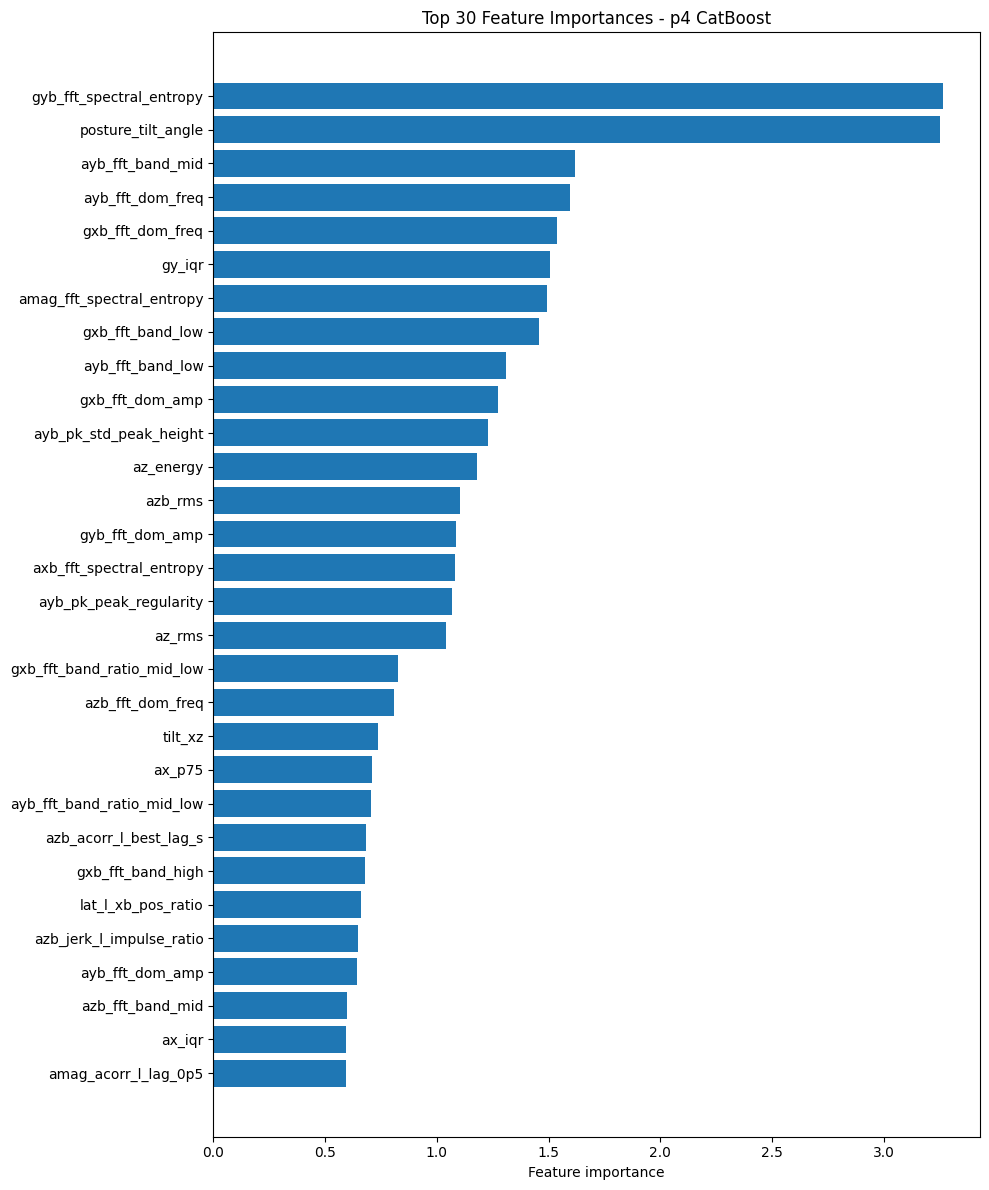

In [18]:

# Feature Importance
import matplotlib.pyplot as plt

fi_lgbm = pd.DataFrame({
    'feature':    feat_cols,
    'importance': lgbm_models[-1].feature_importance(importance_type='gain'),
}).sort_values('importance', ascending=False)

fi_cat = pd.DataFrame({
    'feature': feat_cols,
    'importance': cat_models[-1].get_feature_importance(),
}).sort_values('importance', ascending=False)

p4_tags = ['jerk', 'lat_', 'acorr']

print("Top 30 LGBM features:")
print(fi_lgbm.head(30).to_string(index=False))
print(f"\np4 signal features in LGBM top 30: "
      f"{[f for f in fi_lgbm.head(30)['feature'] if any(tag in f for tag in p4_tags)]}")

print("\nTop 30 CatBoost features:")
print(fi_cat.head(30).to_string(index=False))
print(f"\np4 signal features in CatBoost top 30: "
      f"{[f for f in fi_cat.head(30)['feature'] if any(tag in f for tag in p4_tags)]}")

plt.figure(figsize=(10, 12))
plt.barh(fi_cat['feature'].head(30)[::-1], fi_cat['importance'].head(30)[::-1])
plt.xlabel('Feature importance')
plt.title('Top 30 Feature Importances - p4 CatBoost')
plt.tight_layout()
plt.show()


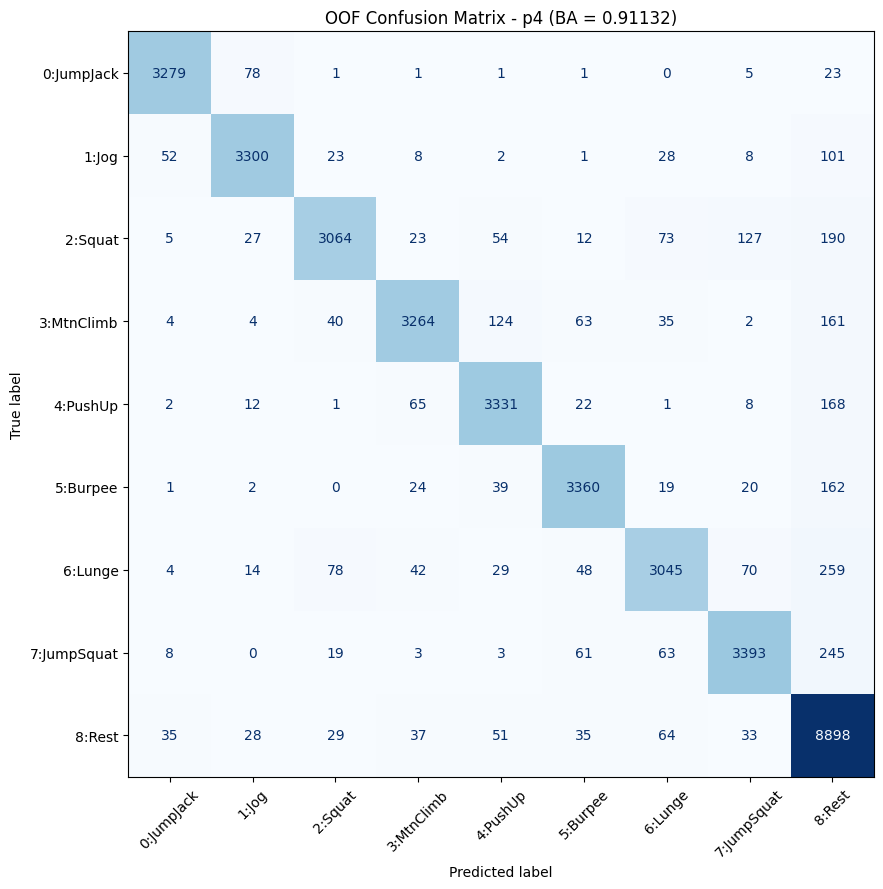


Per-class recall (p4 vs p2):
  0:JumpJack          : 0.968  +0.004 vs p2
  1:Jog               : 0.937  -0.004 vs p2
  2:Squat             : 0.857  -0.008 vs p2
  3:MtnClimb          : 0.883  -0.001 vs p2
  4:PushUp            : 0.923  +0.005 vs p2
  5:Burpee            : 0.926  +0.008 vs p2
  6:Lunge             : 0.848  +0.002 vs p2
  7:JumpSquat         : 0.894  +0.019 vs p2
  8:Rest              : 0.966  +0.001 vs p2

Final OOF BA - p4: 0.91132  (p2 was 0.90851, p3 was 0.87440)


In [19]:

# OOF Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

class_names = [
    '0:JumpJack','1:Jog','2:Squat','3:MtnClimb',
    '4:PushUp','5:Burpee','6:Lunge','7:JumpSquat','8:Rest'
]

cm = confusion_matrix(y_train, final_oof_preds)
fig, ax = plt.subplots(figsize=(11, 9))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
plt.title(f'OOF Confusion Matrix - p4 (BA = {final_ba:.5f})')
plt.tight_layout()
plt.show()

p2_recalls = [0.964, 0.941, 0.865, 0.884, 0.918, 0.918, 0.846, 0.875, 0.965]
print("\nPer-class recall (p4 vs p2):")
for i, name in enumerate(class_names):
    r = cm[i, i] / cm[i].sum() if cm[i].sum() > 0 else 0
    delta = r - p2_recalls[i]
    sign = '+' if delta >= 0 else '-'
    print(f"  {name:20s}: {r:.3f}  {sign}{abs(delta):.3f} vs p2")

print(f"\nFinal OOF BA - p4: {final_ba:.5f}  (p2 was 0.90851, p3 was 0.87440)")
